---
# **Suplementos Alimentares**
---


🎯 **Objetivo:** Verificar qual das três fórmulas de proteína em pó (Fórmula 1, 2 ou 3) proporciona maior ganho de massa muscular em atletas.


---
**Variáveis:**

- `id_produto`: Código identificador do suplemento (Fórmula 1, 2 ou 3). 
- `id_atleta`: Código identificador do atleta que participou do estudo. 
- `ganho_massa`: Quantidade de massa muscular ganha (em kg) após 8 semanas de uso. 
- `idade`: Idade do atleta. 
- `frequencia_treino`: Número médio de treinos semanais do atleta. 
---

Desafio Estatística com Python - Teste de hipóteses
Squad Nina da Hora | Bootcamp Data Analytics 2026.1

In [29]:
# ==============================
# IMPORTACOES
# ==============================

import math
import numpy as np
import pandas as pd

from IPython.display import display, Markdown

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Configuração visual
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

paleta = "flare"
cores = sns.color_palette(paleta, n_colors=2)

In [30]:
# ==============================
# IMPORTACAO DO DATASET 
# ==============================

arquivo = 'bd_suplementos'
url = f'https://raw.githubusercontent.com/Squad-Nina-da-Hora/wmc-desafio-suplementos/main/{arquivo}.csv'
df = pd.read_csv(url)

In [31]:
# ==============================
# PERFIL DO DATASET
# ==============================

linhas = df.shape[0]
colunas = df.shape[1]
print(f"O dataset possui {linhas} linhas e {colunas} colunas.")

display(Markdown("---"))

info_df = pd.DataFrame({
    'Coluna': df.columns,
    'Tipo': df.dtypes.values,
    'Não nulos': df.count().values,
    'Nulos': df.isnull().sum().values
})

info_df

O dataset possui 300 linhas e 5 colunas.


---

,Coluna,Tipo,Não nulos,Nulos
0,id_produto,str,300,0
1,id_atleta,int64,300,0
2,ganho_massa,float64,300,0
3,idade,int64,300,0
4,frequencia_treino,int64,300,0


### Questão 1 — Análise Exploratória dos Dados (EDA)

In [32]:
# Tabela descritiva do ganho de massa para cada suplemento

sup_massa = df.groupby('id_produto')['ganho_massa'].agg(['mean', 'median', 'std', 'count'])
sup_massa.columns = ['Média de Ganho (kg)', 'Mediana de Ganho (kg)', 'Desvio Padrão (kg)', 'Tamanho da Amostra']

sup_massa = sup_massa.round(4)
sup_massa

,Média de Ganho (kg),Mediana de Ganho (kg),Desvio Padrão (kg),Tamanho da Amostra
id_produto,,,,
Fórmula 1,2.6566,2.67,1.3880,99
Fórmula 2,2.3501,2.15,1.3952,94
Fórmula 3,2.3936,2.35,1.5099,107


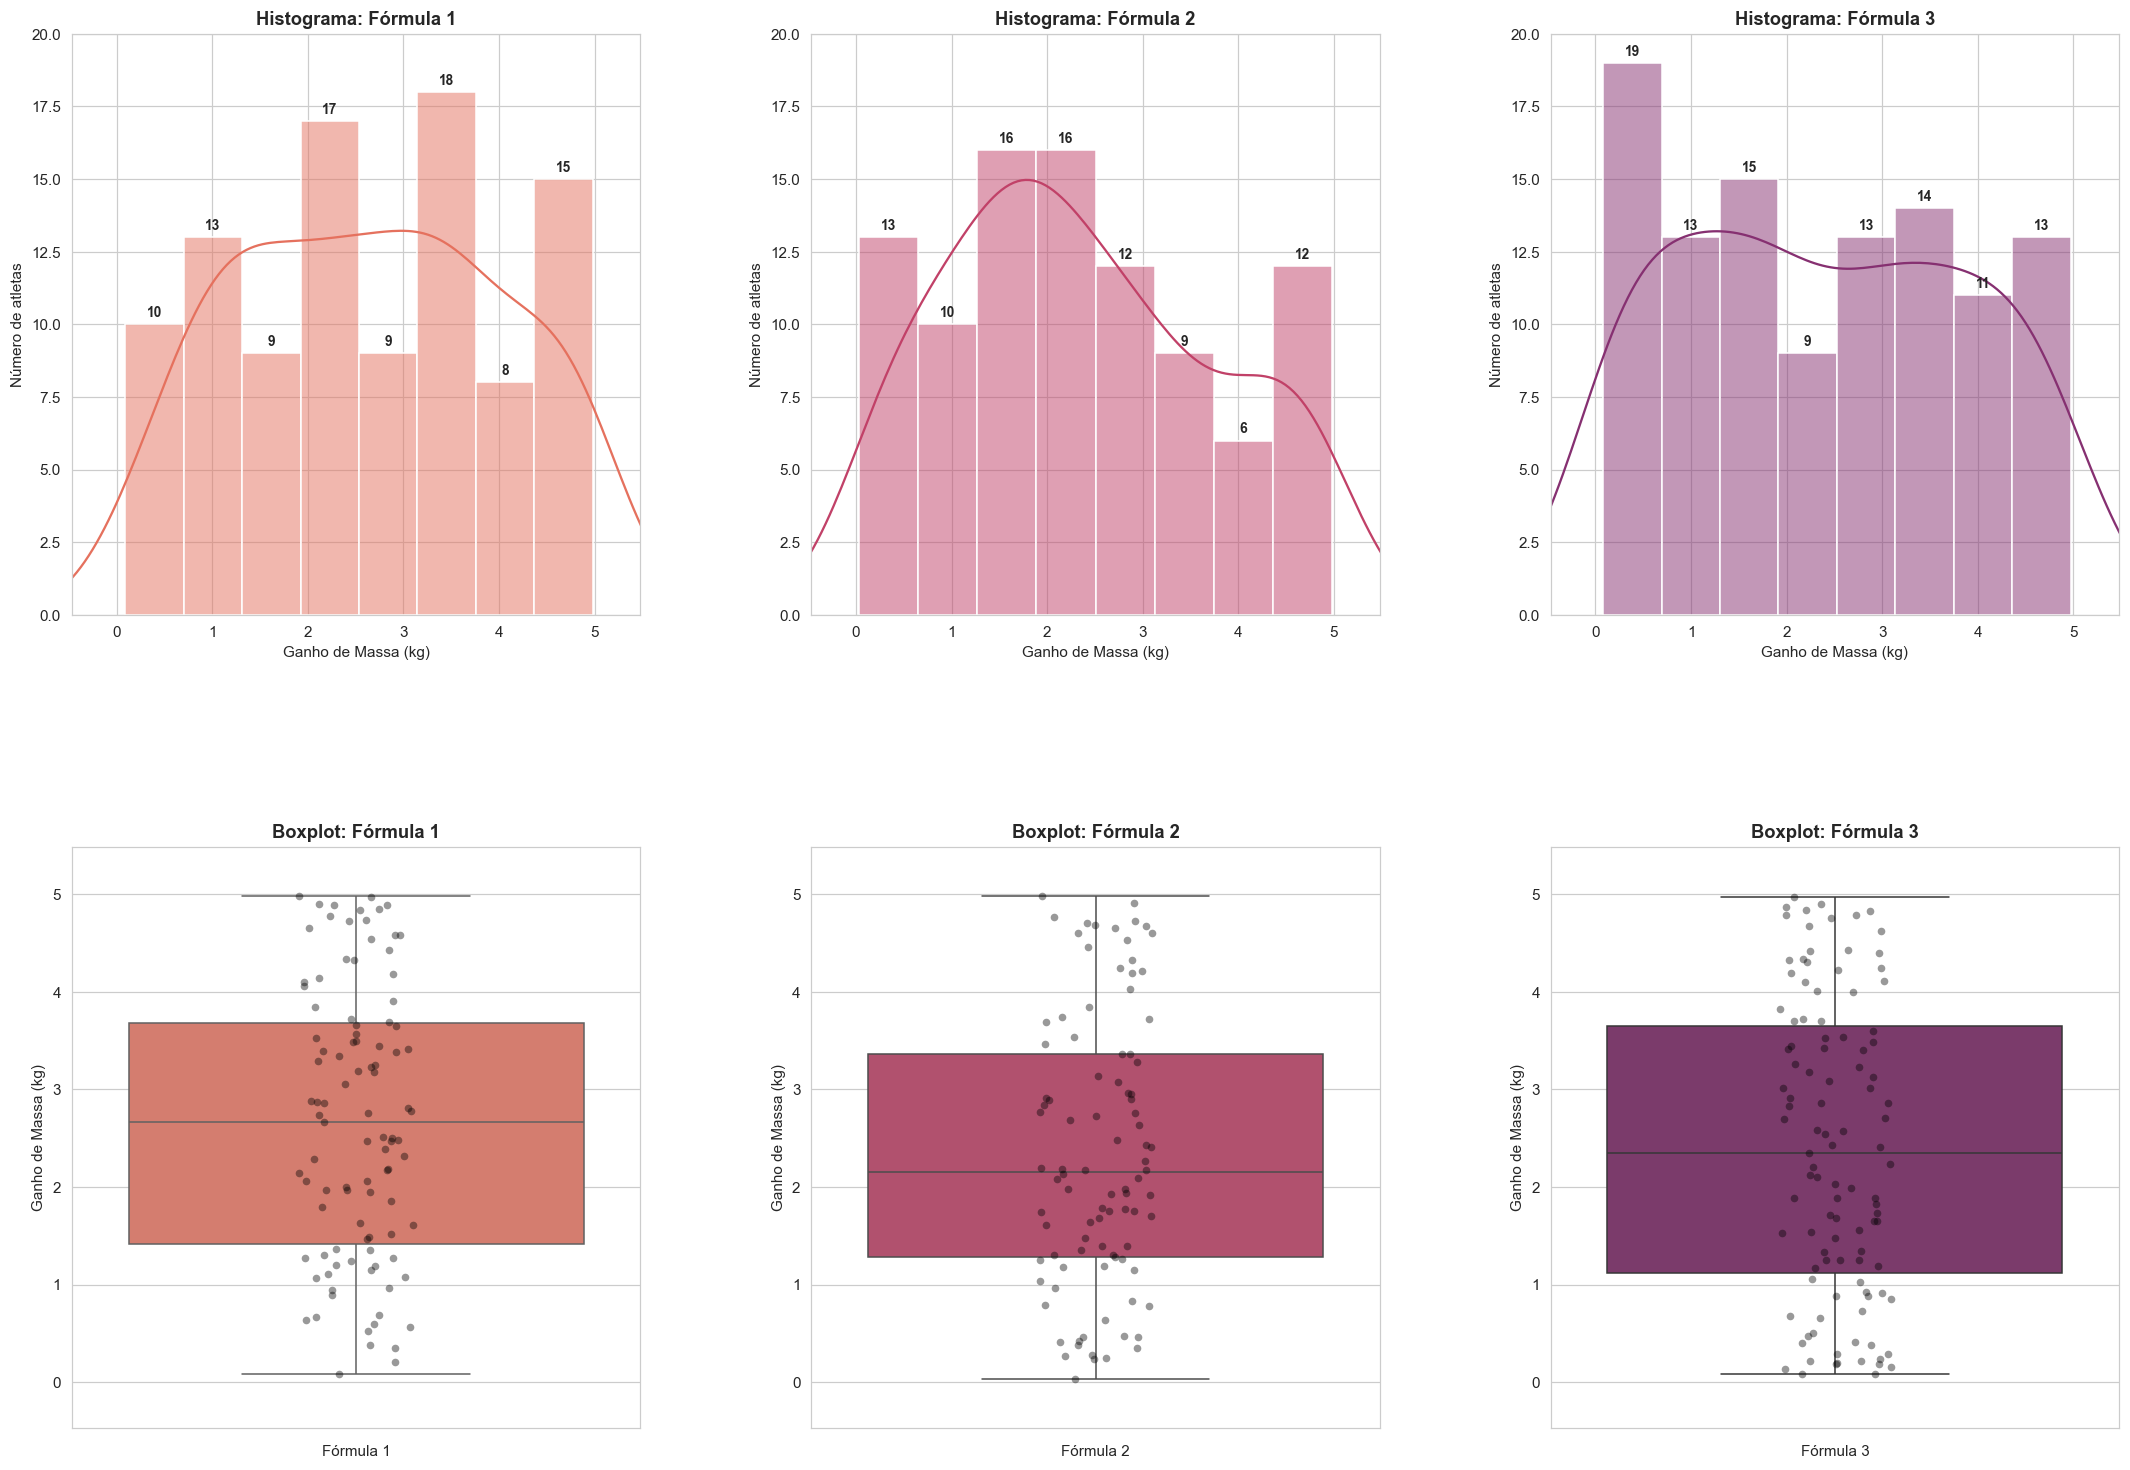

In [33]:
# Ganho de massa para cada suplemento
# Visual da distribuição reorganizado e com eixos padronizados

# Encontra os limites do ganho de massa para a padronização das escalas

ganho_min = df['ganho_massa'].min() - 0.5
ganho_max = df['ganho_massa'].max() + 0.5

limites_atleta = 20

fig, axes = plt.subplots(2, 3, figsize=(20, 14))

produto = sorted(df['id_produto'].unique())

for i, supl in enumerate(produto):
  df_supl = df[df['id_produto'] == supl]
  cor_atual = sns.color_palette('flare', 3)[i]

  # --- Histogramas ---
  sns.histplot(data=df_supl, x='ganho_massa', kde=True, color=cor_atual, stat='count', kde_kws={'cut': 3},ax=axes[0, i])
  axes[0, i].set_title(f'Histograma: {supl}', fontsize=12, weight='bold')
  axes[0, i].set_xlabel('Ganho de Massa (kg)')
  axes[0, i].set_ylabel('Número de atletas')
  
  # Padronizando os eixos X e Y para todos os histogramas
  axes[0, i].set_xlim(ganho_min, ganho_max)
  axes[0, i].set_ylim(0, limites_atleta) 

  # Adiciona os rótulos de contagem no histograma
  if axes[0, i].containers:
      axes[0, i].bar_label(axes[0, i].containers[0], padding=3, fontsize=9, weight='bold')

  # --- Boxplots ---
  sns.boxplot(data=df_supl, y='ganho_massa', color=cor_atual, ax=axes[1, i])
  sns.stripplot(data=df_supl, y='ganho_massa', color='black', alpha=0.4, size=5, jitter=0.1, ax=axes[1, i])
  axes[1, i].set_title(f'Boxplot: {supl}', fontsize=12, weight='bold')
  axes[1, i].set_ylabel('Ganho de Massa (kg)')
  axes[1, i].set_xlabel(supl)
  
  # Padronizando o eixo Y do Boxplot 
  axes[1, i].set_ylim(ganho_min, ganho_max)

# Ajusta o espaçamento 
plt.tight_layout(pad=3.0)
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()


In [34]:
# Outliers pelo método do IQR (geral)
q1 = df['ganho_massa'].quantile(0.25)
q3 = df['ganho_massa'].quantile(0.75)
iqr = q3 - q1

outliers = df[(df['ganho_massa'] < (q1 - 1.5 * iqr)) | (df['ganho_massa'] > (q3 + 1.5 * iqr))]
print(f"Total de outliers encontrados: {len(outliers)}")
outliers

Total de outliers encontrados: 0


,id_produto,id_atleta,ganho_massa,idade,frequencia_treino


# Fazendo análises extras com os dados do nossso dataframe
Seguindo essa ordem:

- Idade para cada Suplemento
- Frequência de treino para cada Suplemento
- Ganho de massa para frequência de treino
- Tabela descritiva do ganho de massa por idade
- Tabela descritiva do ganho de massa para o intervalo de idade criado
- Tabela descritiva da frequência de treino por idade
- Tabela descritiva da frequência de treino para o intervalo de idade criado


In [35]:
# Tabela descritiva da idade para cada suplemento

sup_idade = df.groupby('id_produto')['idade'].agg(['mean', 'median', 'std', 'count'])
sup_idade.columns = ['Média de Idade', 'Mediana de Idade', 'Desvio Padrão', 'Tamanho da Amostra']

sup_idade = sup_idade.round(4)
sup_idade

,Média de Idade,Mediana de Idade,Desvio Padrão,Tamanho da Amostra
id_produto,,,,
Fórmula 1,27.6162,26.0,7.2248,99
Fórmula 2,27.6809,27.0,6.0022,94
Fórmula 3,28.9813,30.0,6.1583,107


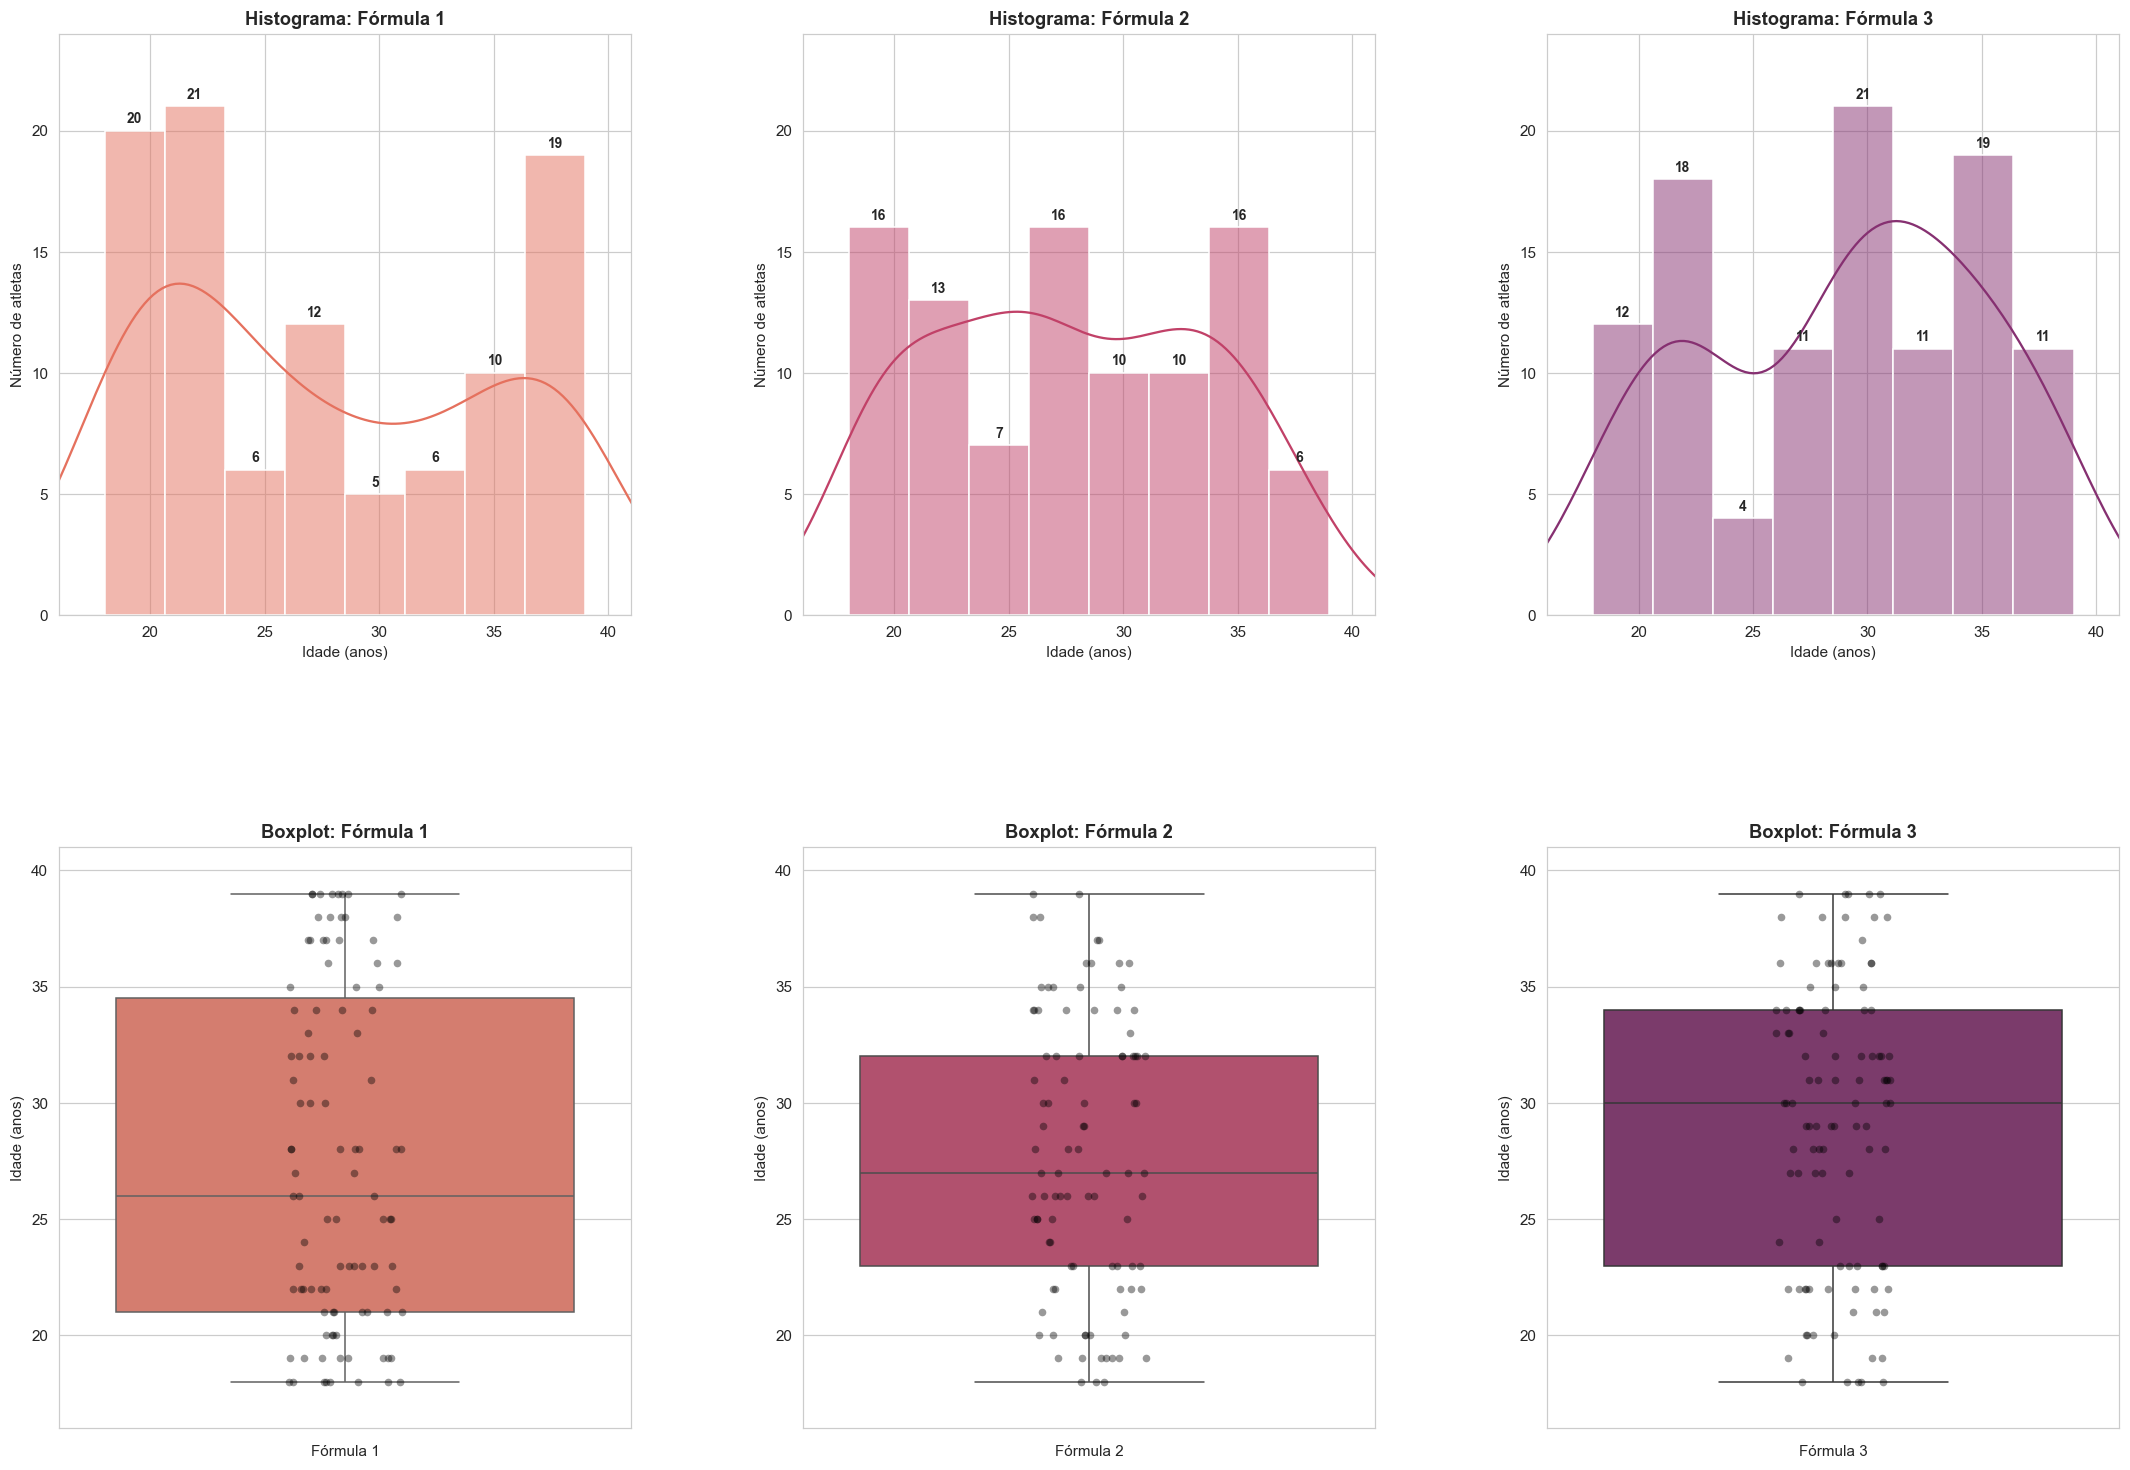

In [36]:
# Idade para cada suplemento
# Visual da distribuição da idade reorganizado e com eixos padronizados

# Encontra os limites da idade para a padronização das escalas

idade_min = df['idade'].min() - 2
idade_max = df['idade'].max() + 2

limite_atletas = 24

fig, axes = plt.subplots(2, 3, figsize=(20, 14))

produto = sorted(df['id_produto'].unique())

for i, supl in enumerate(produto):
  df_supl = df[df['id_produto'] == supl]
  cor_atual = sns.color_palette('flare', 3)[i]

  # --- Histogramas da Idade ---
  sns.histplot(data=df_supl, x='idade', kde=True, color=cor_atual, stat='count', kde_kws={'cut': 3}, ax=axes[0, i])
  axes[0, i].set_title(f'Histograma: {supl}', fontsize=12, weight='bold')
  axes[0, i].set_xlabel('Idade (anos)')
  axes[0, i].set_ylabel('Número de atletas')
  
  # Padronizando os eixos X e Y para todos os histogramas de idade
  axes[0, i].set_xlim(idade_min, idade_max)
  axes[0, i].set_ylim(0, limite_atletas)

  # Adiciona os rótulos de contagem no histograma
  if axes[0, i].containers:
      axes[0, i].bar_label(axes[0, i].containers[0], padding=3, fontsize=9, weight='bold')

  # --- Boxplots da Idade ---
  sns.boxplot(data=df_supl, y='idade', color=cor_atual, ax=axes[1, i])
  sns.stripplot(data=df_supl, y='idade', color='black', alpha=0.4, size=5, jitter=0.1, ax=axes[1, i])
  axes[1, i].set_title(f'Boxplot: {supl}', fontsize=12, weight='bold')
  axes[1, i].set_ylabel('Idade (anos)')
  axes[1, i].set_xlabel(supl)
  
  # Padronizando o eixo Y do Boxplot 
  axes[1, i].set_ylim(idade_min, idade_max)

# Ajusta os espaçamentos 
plt.tight_layout(pad=3.0)
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()


In [37]:
# Outliers pelo método do IQR (geral)
q1 = df['idade'].quantile(0.25)
q3 = df['idade'].quantile(0.75)
iqr = q3 - q1

outliers = df[(df['idade'] < (q1 - 1.5 * iqr)) | (df['idade'] > (q3 + 1.5 * iqr))]
print(f"Total de outliers encontrados: {len(outliers)}")
outliers

Total de outliers encontrados: 0


,id_produto,id_atleta,ganho_massa,idade,frequencia_treino


In [38]:
# Tabela descritiva da frequência de treino para cada suplemento

sup_treino = df.groupby('id_produto')['frequencia_treino'].agg(['mean', 'median', 'std', 'count'])
sup_treino.columns = ['Média de Treinos', 'Mediana de Treinos', 'Desvio Padrão', 'Tamanho da Amostra']

sup_treino = sup_treino.round(4)
sup_treino

,Média de Treinos,Mediana de Treinos,Desvio Padrão,Tamanho da Amostra
id_produto,,,,
Fórmula 1,4.0505,4.0,1.4454,99
Fórmula 2,4.0532,4.0,1.4246,94
Fórmula 3,3.8879,4.0,1.4297,107


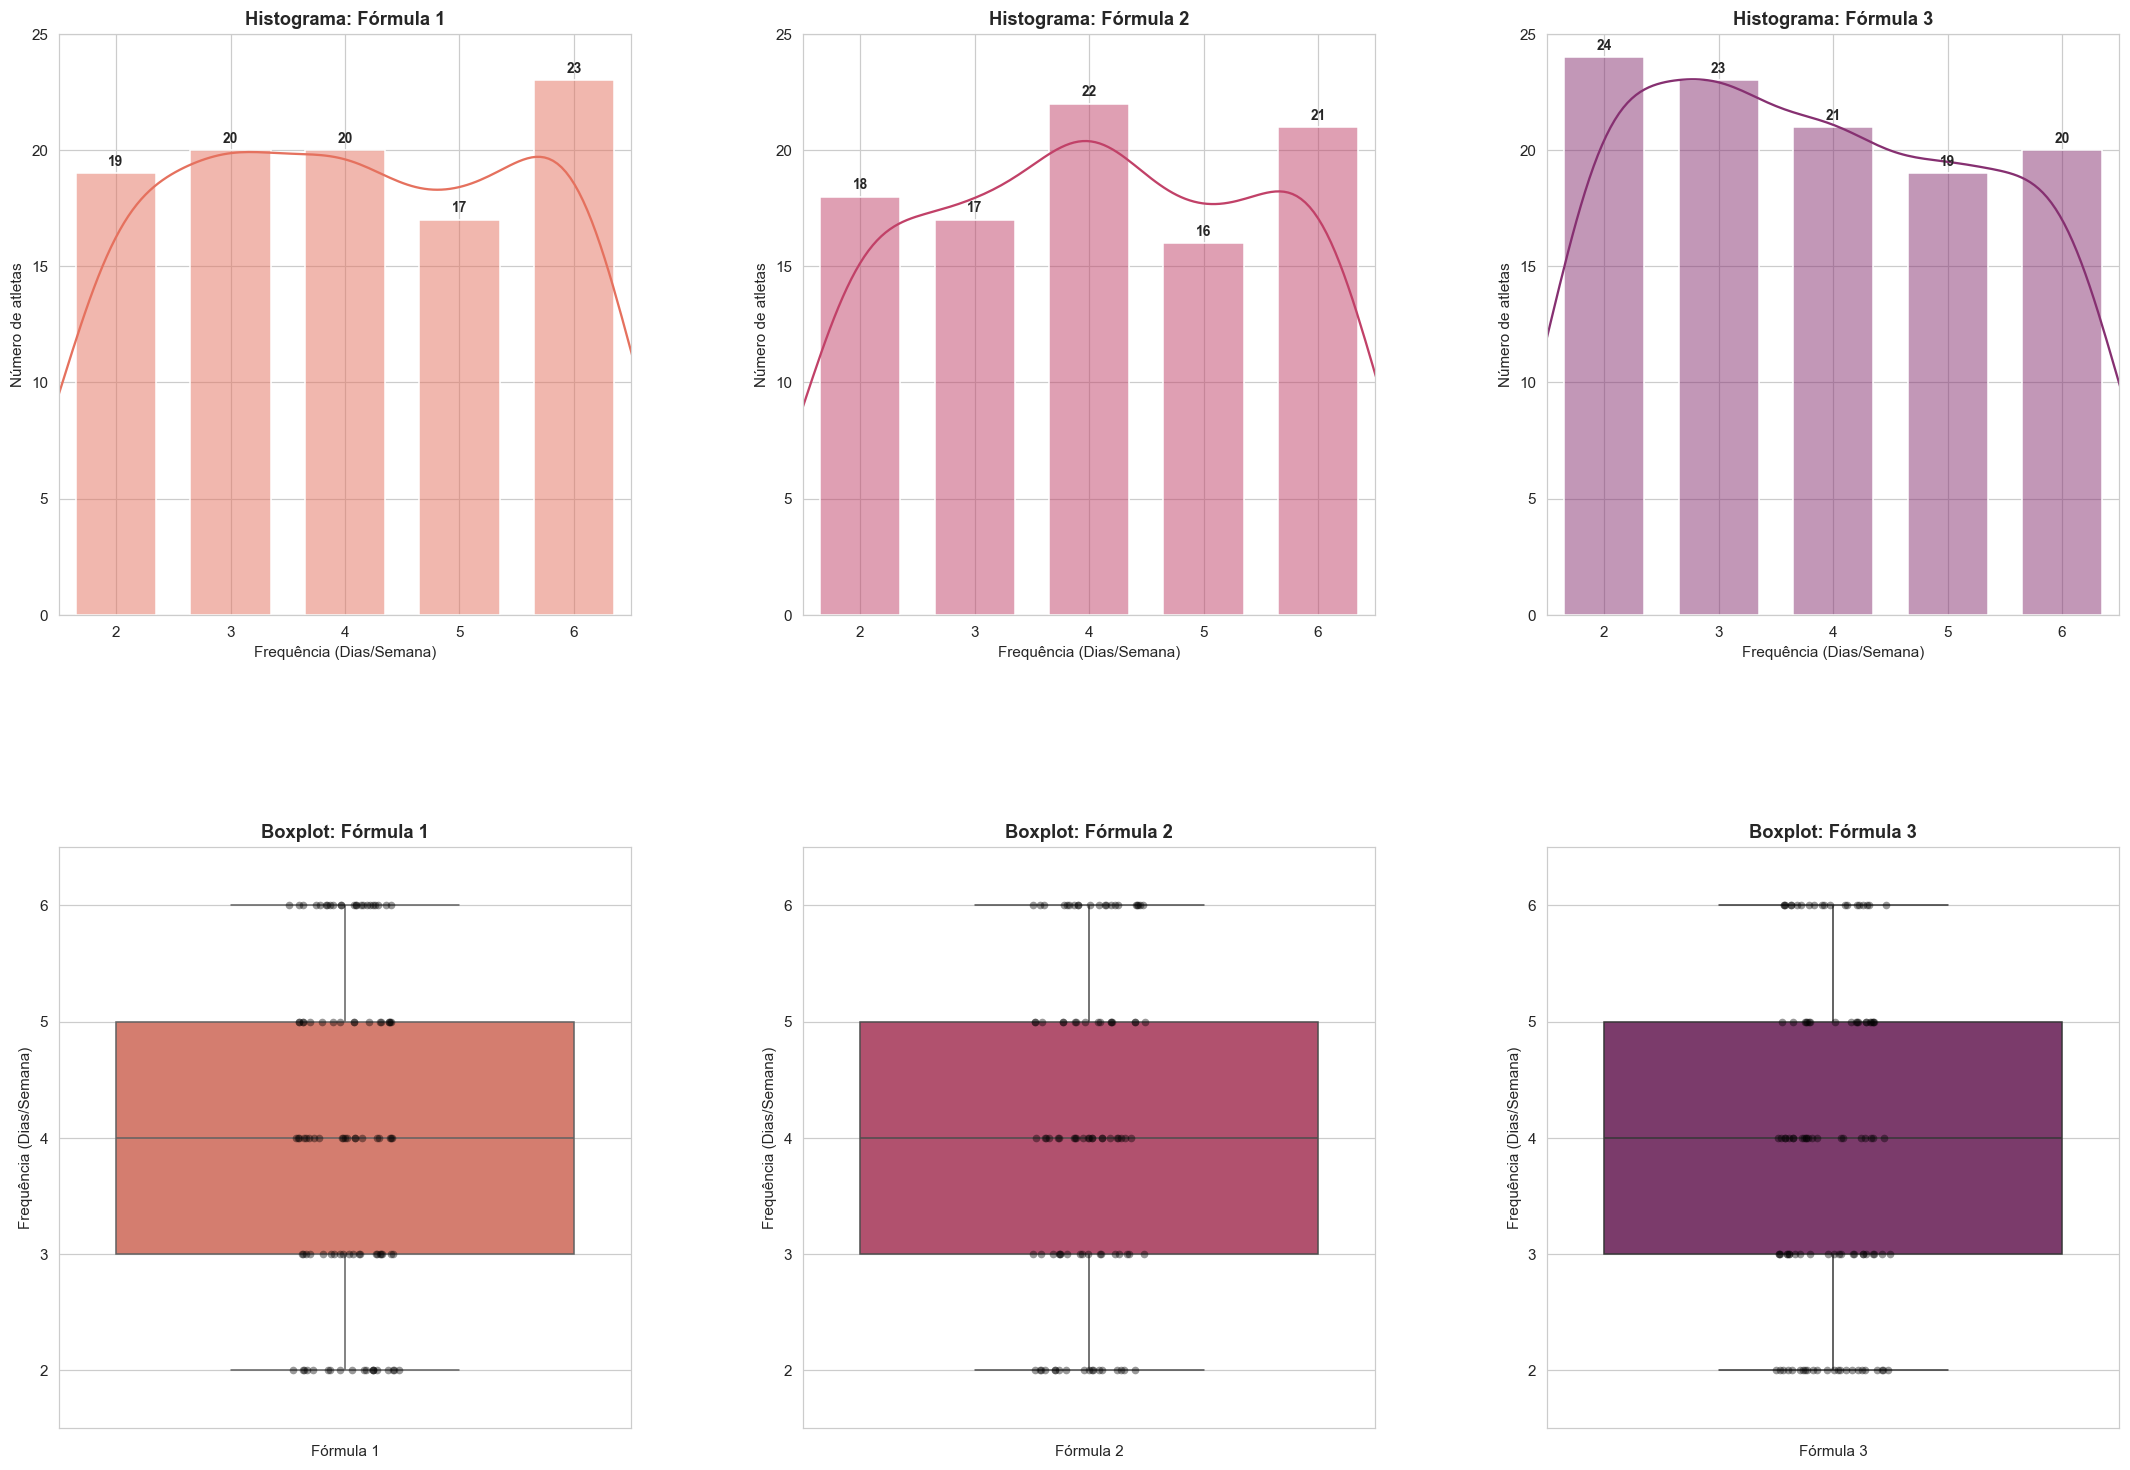

In [39]:
# Frequência de treino para cada suplemento
# Visual da distribuição da frequência de treino por produto reorganizado e com eixos padronizados

# Encontra os limites da frequência de treino para a padronização das escalas

treino_min = df['frequencia_treino'].min() - 0.5
treino_max = df['frequencia_treino'].max() + 0.5

limite_atleta_freq = 25

fig, axes = plt.subplots(2, 3, figsize=(20, 14))

produto = sorted(df['id_produto'].unique())

for i, supl in enumerate(produto):
  df_supl = df[df['id_produto'] == supl]
  cor_atual = sns.color_palette('flare', 3)[i]

  # --- Histogramas das Frequências ---
  sns.histplot(data=df_supl, x='frequencia_treino', kde=True, color=cor_atual, stat='count', discrete=True, shrink=0.7, kde_kws={'cut': 3}, ax=axes[0, i])
  axes[0, i].set_title(f'Histograma: {supl}', fontsize=12, weight='bold')
  axes[0, i].set_xlabel('Frequência (Dias/Semana)')
  axes[0, i].set_ylabel('Número de atletas')
  
  # Padronizando os eixos X e Y para todos os histogramas de treino
  axes[0, i].set_xlim(treino_min, treino_max)
  axes[0, i].set_ylim(0, limite_atleta_freq)

  # Adiciona os rótulos de contagem no histograma
  if axes[0, i].containers:
      axes[0, i].bar_label(axes[0, i].containers[0], padding=3, fontsize=9, weight='bold')

  # --- Boxplots das frequências ---
  sns.boxplot(data=df_supl, y='frequencia_treino', color=cor_atual, ax=axes[1, i])
  sns.stripplot(data=df_supl, y='frequencia_treino', color='black', alpha=0.4, size=5, jitter=0.1, ax=axes[1, i])
  axes[1, i].set_title(f'Boxplot: {supl}', fontsize=12, weight='bold')
  axes[1, i].set_ylabel('Frequência (Dias/Semana)')
  axes[1, i].set_xlabel(supl)
  
  # Padronizando o eixo Y do Boxplot
  axes[1, i].set_ylim(treino_min, treino_max)

# Ajusta os espaçamentos
plt.tight_layout(pad=3.0)
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()


In [40]:
# Outliers pelo método do IQR (geral)
q1 = df['frequencia_treino'].quantile(0.25)
q3 = df['frequencia_treino'].quantile(0.75)
iqr = q3 - q1

outliers = df[(df['frequencia_treino'] < (q1 - 1.5 * iqr)) | (df['frequencia_treino'] > (q3 + 1.5 * iqr))]
print(f"Total de outliers encontrados: {len(outliers)}")
outliers

Total de outliers encontrados: 0


,id_produto,id_atleta,ganho_massa,idade,frequencia_treino


In [41]:
# Tabela descritiva do ganho de massa para a frequência de treino

freq_massa = df.groupby('frequencia_treino')['ganho_massa'].agg(['mean', 'median', 'std', 'count'])
freq_massa.columns = ['Média de Ganho (kg)', 'Mediana de Ganho (kg)', 'Desvio Padrão (kg)', 'Tamanho da Amostra']
freq_massa = freq_massa.round(4)
freq_massa

,Média de Ganho (kg),Mediana de Ganho (kg),Desvio Padrão (kg),Tamanho da Amostra
frequencia_treino,,,,
2,2.5797,2.640,1.4195,61
3,2.1610,2.075,1.3643,60
4,2.3225,2.170,1.3395,63
5,2.4150,2.445,1.5483,52
6,2.8297,2.705,1.4715,64


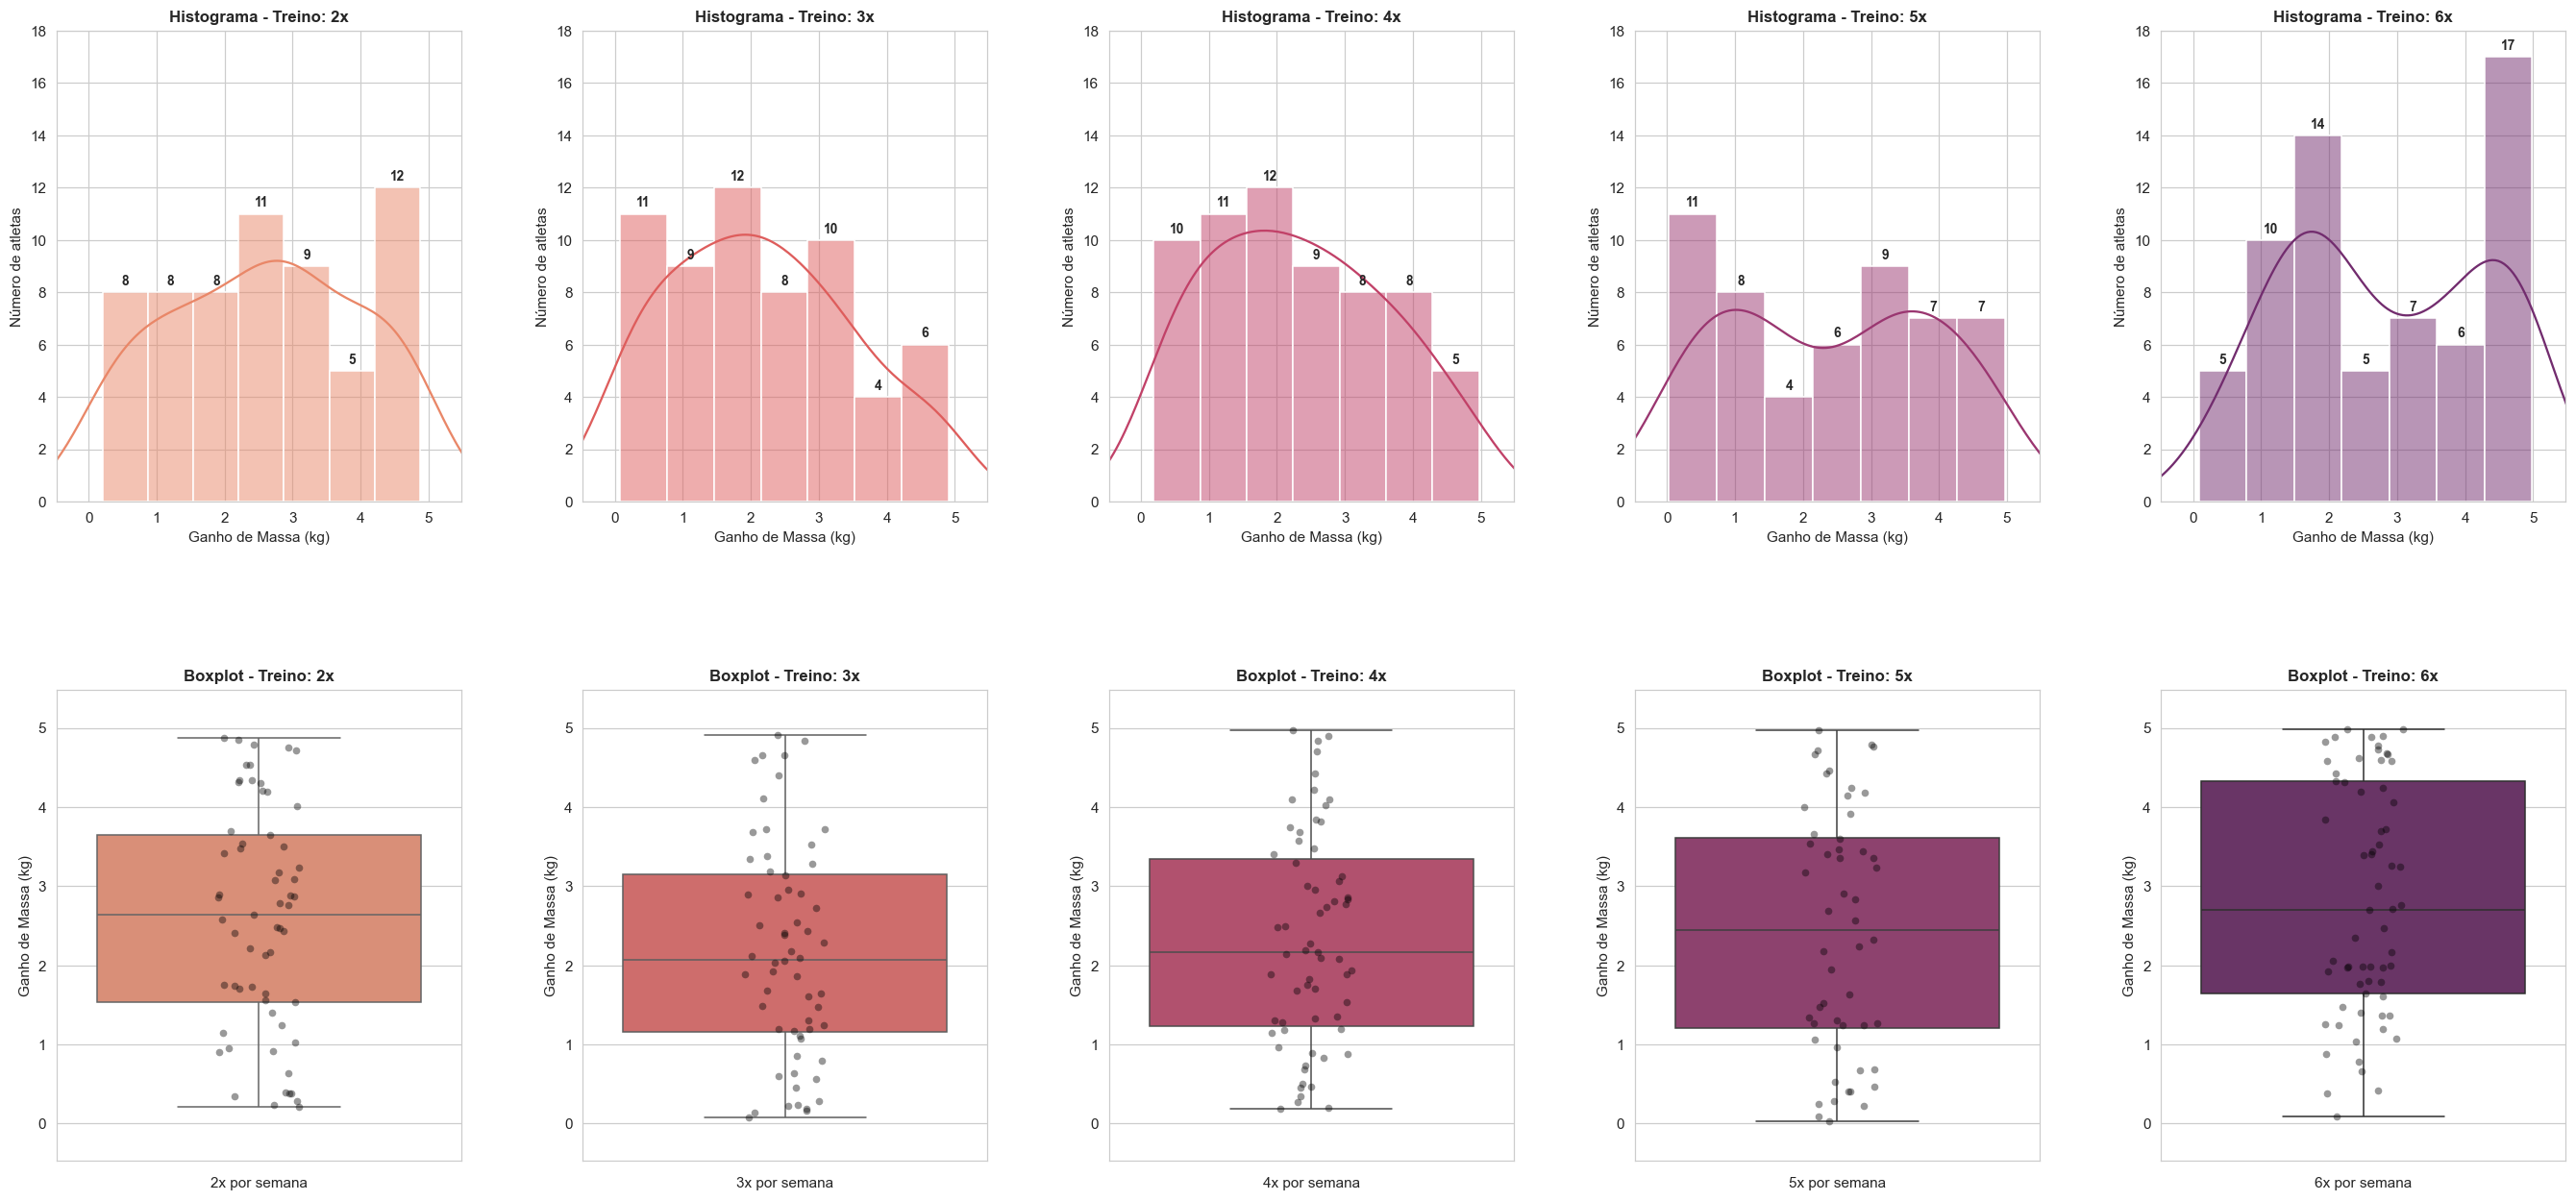

In [42]:
# Ganho de massa para cada frequência de treino
# Visual da distribuição por Frequência de Treino reorganizado e com eixos padronizados

# Encontra os limites globais do ganho de massa para a padronização das escalas
ganho_min = df['ganho_massa'].min() - 0.5
ganho_max = df['ganho_massa'].max() + 0.5

limites_atleta = 18

# Descobre quantas frequências de treino diferentes existem para criar o número certo de colunas
frequencias_ordenadas = sorted(df['frequencia_treino'].unique())
num_colunas = len(frequencias_ordenadas)

fig, axes = plt.subplots(2, num_colunas, figsize=(5 * num_colunas, 12))

for i, freq in enumerate(frequencias_ordenadas):
  df_freq = df[df['frequencia_treino'] == freq]
  cor_atual = sns.color_palette('flare', num_colunas)[i]

  # ---Histogramas ---
  sns.histplot(data=df_freq, x='ganho_massa', kde=True, color=cor_atual, stat='count', kde_kws={'cut': 3}, ax=axes[0, i])
  axes[0, i].set_title(f'Histograma - Treino: {freq}x', fontsize=11, weight='bold')
  axes[0, i].set_xlabel('Ganho de Massa (kg)')
  axes[0, i].set_ylabel('Número de atletas')
  
  # Padronizando os eixos X e Y para todos os histogramas
  axes[0, i].set_xlim(ganho_min, ganho_max)
  axes[0, i].set_ylim(0, limites_atleta)

  # Adiciona os rótulos de contagem no histograma
  if axes[0, i].containers:
      axes[0, i].bar_label(axes[0, i].containers[0], padding=3, fontsize=9, weight='bold')

  # ---Boxplots ---
  sns.boxplot(data=df_freq, y='ganho_massa', color=cor_atual, ax=axes[1, i])
  sns.stripplot(data=df_freq, y='ganho_massa', color='black', alpha=0.4, size=5, jitter=0.1, ax=axes[1, i])
  axes[1, i].set_title(f'Boxplot - Treino: {freq}x', fontsize=11, weight='bold')
  axes[1, i].set_ylabel('Ganho de Massa (kg)')
  axes[1, i].set_xlabel(f'{freq}x por semana')
  
  # Padronizando o eixo Y de todos os Boxplots
  axes[1, i].set_ylim(ganho_min, ganho_max)

# Ajusta os espaçamentos
plt.tight_layout(pad=3.0)
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()


In [43]:
# Tabela descritiva do ganho de massa por idade

idade_massa = df.groupby('idade')['ganho_massa'].agg(['mean', 'median', 'std', 'count'])
idade_massa.columns = ['Média de Ganho (kg)', 'Mediana de Ganho (kg)', 'Desvio Padrão (kg)', 'Tamanho da Amostra']

idade_massa = idade_massa.round(4)
idade_massa

,Média de Ganho (kg),Mediana de Ganho (kg),Desvio Padrão (kg),Tamanho da Amostra
idade,,,,
18,2.9194,2.765,1.5218,16
19,2.5161,2.570,1.5334,18
20,2.3771,2.175,1.2827,14
21,2.6400,2.585,1.5854,12
22,2.6905,2.860,1.3236,21
23,2.4079,2.190,1.3419,19
24,2.1580,1.790,1.7946,5
25,2.4250,2.265,1.6240,12
26,2.7200,2.080,1.5322,11


In [44]:
# Dividindo a quantidade de idade em intervalos

# 1. Definir as três condições lógicas
condicoes = [
    (df['idade'] <= 24),                              # De 18 a 24 anos
    (df['idade'] >= 25) & (df['idade'] <= 31),        # De 25 a 31 anos
    (df['idade'] >= 32)                               # De 32 a 39 anos
]

# 2. Definir os rótulos correspondentes para cada condição
rotulos = ['18 a 24 anos', '25 a 31 anos', '32 a 39 anos']

# 3. Cria a coluna nova preenchida com um valor padrão
df['faixa_etaria'] = 'Não identificado'

for condicao, rotulo in zip(condicoes, rotulos):
    df.loc[condicao, 'faixa_etaria'] = rotulo

# 5. Verifica quantas pessoas caíram em cada grupo
df['faixa_etaria'].value_counts()

faixa_etaria
32 a 39 anos    108
18 a 24 anos    105
25 a 31 anos     87
Name: count, dtype: int64

In [45]:
# Tabela descritiva do ganho de massa para o intervalo de idade criado

idade_ganho = df.groupby('faixa_etaria')['ganho_massa'].agg(['mean', 'median', 'std', 'count'])
idade_ganho.columns = ['Média de Ganho (kg)', 'Mediana de Ganho (kg)', 'Desvio Padrão (kg)', 'Tamanho da Amostra']

idade_ganho = idade_ganho.round(4)
idade_ganho

,Média de Ganho (kg),Mediana de Ganho (kg),Desvio Padrão (kg),Tamanho da Amostra
faixa_etaria,,,,
18 a 24 anos,2.5714,2.50,1.4153,105
25 a 31 anos,2.4933,2.32,1.4621,87
32 a 39 anos,2.3435,2.19,1.4400,108


In [46]:
# Tabela descritiva da frequência de treino por idade

idade_treino = df.groupby('idade')['frequencia_treino'].agg(['mean', 'median', 'std', 'count'])
idade_treino.columns = ['Média de Treino', 'Mediana de Treino', 'Desvio Padrão', 'Tamanho da Amostra']

idade_treino = idade_treino.round(4)
idade_treino

,Média de Treino,Mediana de Treino,Desvio Padrão,Tamanho da Amostra
idade,,,,
18,4.4375,4.5,1.5478,16
19,3.9444,4.0,1.3492,18
20,3.8571,3.5,1.6104,14
21,4.3333,5.0,1.4975,12
22,4.2381,4.0,1.4108,21
23,4.1579,4.0,1.3850,19
24,4.4000,4.0,1.5166,5
25,3.5000,3.5,1.3817,12
26,4.4545,4.0,1.5076,11


In [47]:
# Tabela descritiva para o intervalo de idade criado

idade_freq = df.groupby('faixa_etaria')['frequencia_treino'].agg(['mean', 'median', 'std', 'count'  ])
idade_freq.columns = ['Média de Frequência', 'Mediana de Frequência', 'Desvio Padrão', 'Tamanho da Amostra']

idade_freq = idade_freq.round(4)
idade_freq

,Média de Frequência,Mediana de Frequência,Desvio Padrão,Tamanho da Amostra
faixa_etaria,,,,
18 a 24 anos,4.1714,4.0,1.4308,105
25 a 31 anos,4.0115,4.0,1.4824,87
32 a 39 anos,3.8056,4.0,1.3771,108


### Questão 2 — Existe diferença estatisticamente significativa entre as fórmulas?

- $H_0$: Não há diferença entre as fórmulas.
- $H_1$: Há diferença significativa entre pelo menos duas fórmulas.

In [48]:
alfa = 0.05 # Limite de erro, nivel de significancia

# Preparacao dos grupos
df_massa = df['ganho_massa']
grupo_01 = df_massa[df['id_produto'] == produto[0]]
grupo_02 = df_massa[df['id_produto'] == produto[1]]
grupo_03 = df_massa[df['id_produto'] == produto[2]]

#### Verificação de Normalidade - Shapiro-Wilk

In [49]:
for nome, grupo in zip(produto, [grupo_01, grupo_02, grupo_03]):
  stat, p = stats.shapiro(grupo)
  print(f"{nome}: p-value = {p:.4f} ({'Não ' if p <= alfa else ''}Normal)")

Fórmula 1: p-value = 0.0036 (Não Normal)
Fórmula 2: p-value = 0.0018 (Não Normal)
Fórmula 3: p-value = 0.0002 (Não Normal)


#### Teste Não-Paramétrico - Kruskal-Wallis
Porque os dados não são normais.

In [50]:
stat_k, p_kruskal = stats.kruskal(grupo_01, grupo_02, grupo_03)
print(f"Estatística H: {stat_k:.4f}")
print(f"p-value: {p_kruskal:.4f}")

print(f"\nCONCLUSÃO: {'Sim,' if p_kruskal < alfa else 'Não'} existe diferença estatisticamente significativa entre as fórmulas.")

Estatística H: 2.6473
p-value: 0.2662

CONCLUSÃO: Não existe diferença estatisticamente significativa entre as fórmulas.


#### ANOVA - Apenas para comparação

In [51]:
f_stat, p_anova = stats.f_oneway(grupo_01, grupo_02, grupo_03)
print(f"p-value ANOVA: {p_anova:.4f}")

p-value ANOVA: 0.2697


**Conclusão:**
Como o p-valor de **0.2662** encontrado no Kruskal-Wallis é superior ao nível de significância adotado, **não rejeitamos a hipótese nula ($H_0$)**. Portanto, não há evidências estatísticas de que as fórmulas 1, 2 e 3 proporcionem ganhos de massa muscular significativamente diferentes entre si nesta amostra.

### Questão 3 — Correlação entre idade e ganho de massa muscular

### Questão 4 — Frequência de treino x ganho de massa (independente do suplemento)

### Questão 5 — Interação entre idade, frequência de treino e eficácia do suplemento

In [52]:
# Define a lista global de produtos de forma única e ordenada para padronizar todos os loops e análises subsequentes

produtos_ordenados = sorted(df['id_produto'].unique())

In [53]:
# Cria um dicionário com os dados filtrados de cada produto para usar em todos os loops seguintes do notebook

dados_por_produto = {}

for prod in produtos_ordenados:
    df_filtrado = df[df['id_produto'] == prod]
    dados_por_produto[prod] = df_filtrado

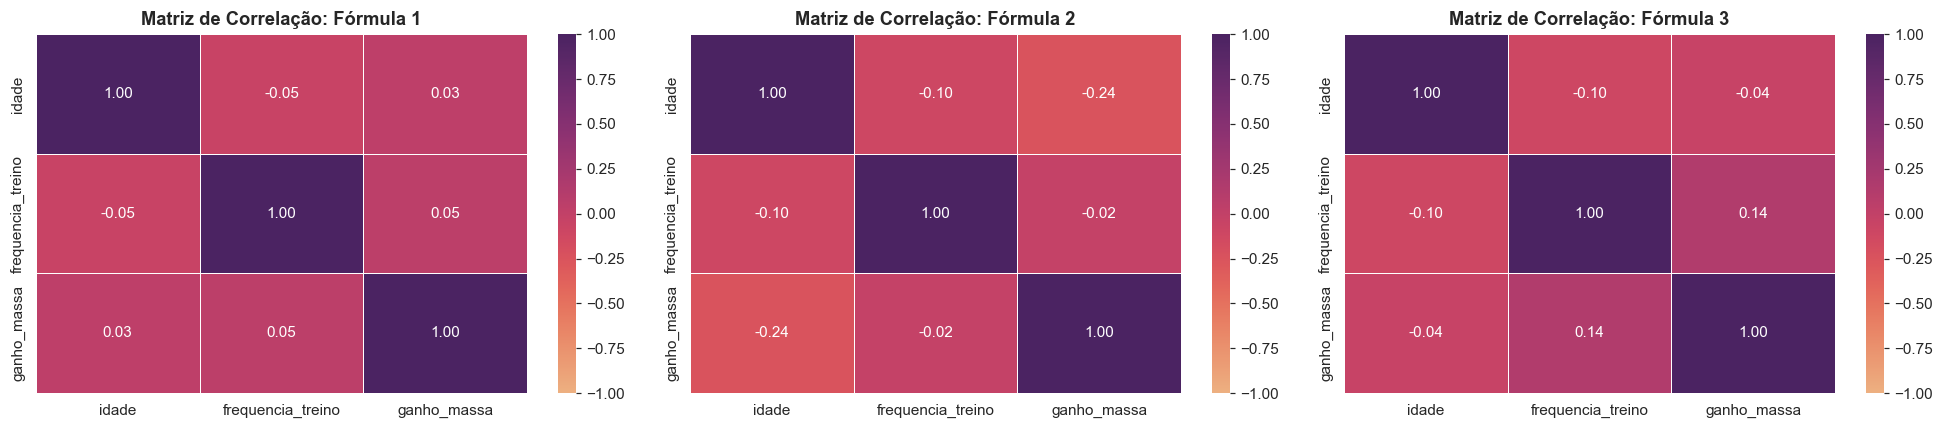

In [54]:
# Exibe heatmaps para avaliar as correlações cruzadas por produto

plt.figure(figsize=(18, 4))

# Seleciona colunas que iremos cruzar
colunas_analise = ['idade', 'frequencia_treino', 'ganho_massa']

for i, produto in enumerate(produtos_ordenados, 1):
    plt.subplot(1, 3, i)
    
    # Calcula a matriz de correlação de Spearman apenas para as 3 variáveis daquele produto
    matriz_corr = dados_por_produto[produto][colunas_analise].corr(method='spearman')
    
    # Plota o mapa de calor com rótulos dos valores (annot=True)
    sns.heatmap(
        matriz_corr, 
        annot=True, 
        cmap=paleta, 
        vmin=-1, 
        vmax=1, 
        fmt=".2f", 
        linewidths=0.5
    )
    
    plt.title(f'Matriz de Correlação: {produto}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

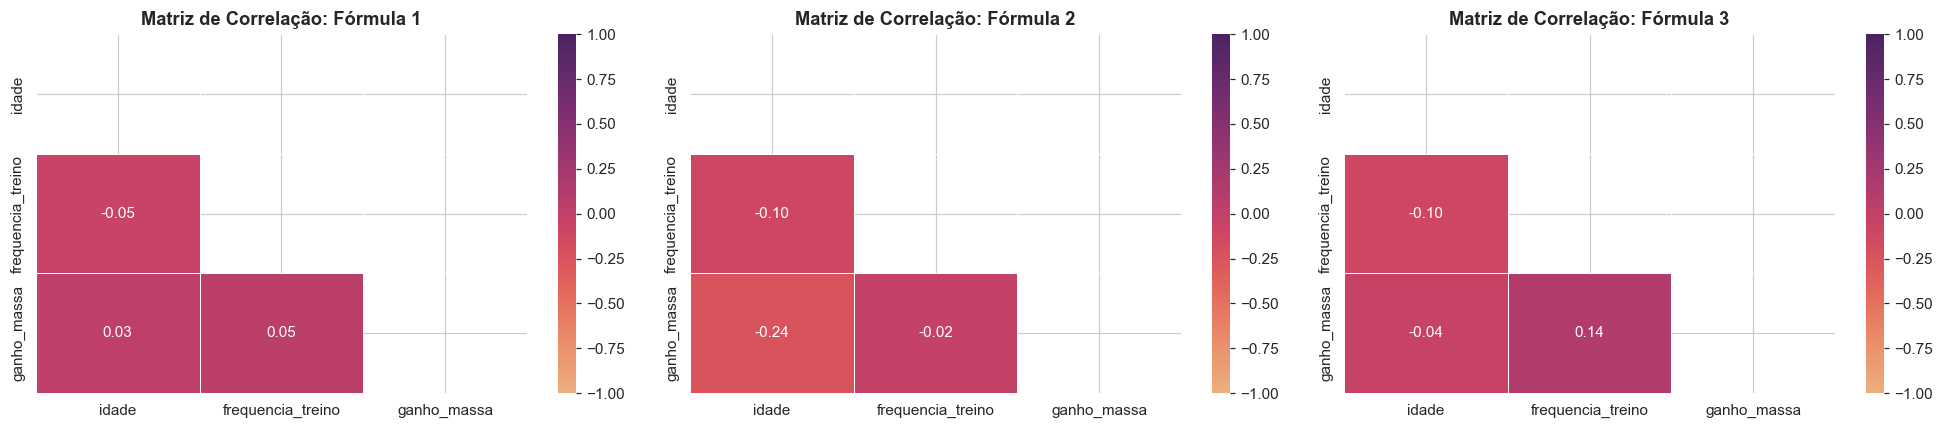

In [55]:
# Exibe heatmaps limpos
# OBS: refaz os heatmaps, aplicando uma máscara que remove os resultados duplicados ou inúteis (dada variável por ela mesma)

plt.figure(figsize=(18, 4))

# Seleciona colunas que iremos cruzar
colunas_analise = ['idade', 'frequencia_treino', 'ganho_massa']

for i, produto in enumerate(produtos_ordenados, 1):
    plt.subplot(1, 3, i)
    
    # Calcula a matriz de correlação de Spearman apenas para as 3 variáveis daquele produto
    matriz_corr = dados_por_produto[produto][colunas_analise].corr(method='spearman')
    
    # Aplica uma máscara que esconde a diagonal e a parte espelhada
    mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))
    
    # Plota o heatmap aplicando a máscara
    sns.heatmap(
        matriz_corr, 
        mask=mascara,        # Ativa a máscara aqui!
        annot=True, 
        cmap=paleta, 
        vmin=-1, 
        vmax=1, 
        fmt=".2f", 
        linewidths=0.5
    )
    
    plt.title(f'Matriz de Correlação: {produto}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [56]:
# Não existe uma correlação geral e forte entre essas três variáveis juntas, mas existem comportamentos específicos e sutis quando olhamos para cada fórmula separadamente:
# Fórmula 1: Nenhuma correlação. Idade, frequência de treino e ganho de massa não têm qualquer relação entre si nessa fórmula (todos os valores são praticamente zero, variando entre $0.03$ e $-0.05$). O suplemento funciona de forma independente do perfil do atleta.
# Fórmula 2 (Efeito da Idade): Existe uma correlação negativa fraca ($-0.24$) entre a Idade e o Ganho de Massa. Isso indica uma tendência de que o suplemento perca um pouco de eficácia à medida que a idade do atleta aumenta. A frequência de treino não interfere aqui.
# Fórmula 3 (Efeito do Treino): Existe uma correlação positiva fraca ($0.14$) entre a Frequência de Treino e o Ganho de Massa. Isso sugere que atletas que treinam mais dias na semana tendem a ter um resultado ligeiramente melhor com essa fórmula específica. A idade não interfere aqui.

###  Questão 6 — Qual fórmula recomendar para atletas que treinam mais de 5x/semana?

In [57]:
# Cria subconjunto apenas com atletas que treinam mais de 5 vezes por semana

atletas_frequentes = df[df['frequencia_treino'] > 5]
atletas_frequentes

,id_produto,id_atleta,ganho_massa,idade,frequencia_treino,faixa_etaria
2,Fórmula 3,3,0.88,30,6,25 a 31 anos
3,Fórmula 3,4,0.09,22,6,18 a 24 anos
4,Fórmula 1,5,2.47,18,6,18 a 24 anos
10,Fórmula 3,11,2.71,28,6,25 a 31 anos
15,Fórmula 1,16,4.89,18,6,18 a 24 anos
...,...,...,...,...,...,...
278,Fórmula 1,279,1.97,23,6,18 a 24 anos
286,Fórmula 1,287,1.80,28,6,25 a 31 anos
290,Fórmula 2,291,1.40,20,6,18 a 24 anos
291,Fórmula 1,292,2.06,20,6,18 a 24 anos


In [58]:
# Cálculo de média, desvio padrão e contagem de registros (atletas) por fórmula, exibindo os resultados em tabela

estat_atletas_frequentes = atletas_frequentes.groupby('id_produto')['ganho_massa'].agg(
    media='mean',
    desvio_padrao='std',
    quantidade='count'
)

print("--- ANÁLISE DESCRITIVA (TREINO > 5 VEZES/SEMANA) ---")
estat_atletas_frequentes

--- ANÁLISE DESCRITIVA (TREINO > 5 VEZES/SEMANA) ---


,media,desvio_padrao,quantidade
id_produto,,,
Fórmula 1,3.012609,1.437884,23
Fórmula 2,2.566190,1.566137,21
Fórmula 3,2.896000,1.442773,20


In [59]:
# Teste estatístico de normalidade: Shapiro-Wilk
# OBS: para aplicar ANOVA, o ganho de massa em cada grupo deve ser aproximadamente normal

print('--- Teste de Normalidade de Shapiro-Wilk (Alfa = 0.05) ---')
print("Hipótese Nula (H0): Os dados do subgrupo seguem uma distribuição normal.")
print("Hipótese Alternativa (H1): Os dados do subgrupo NÃO seguem uma distribuição normal.")
print("-" * 60)

for formula in ['Fórmula 1', 'Fórmula 2', 'Fórmula 3']:
    dados_subgrupo = atletas_frequentes[atletas_frequentes['id_produto'] == formula]['ganho_massa']
    _, p_shap_subgrupo = stats.shapiro(dados_subgrupo)    
    print(f" - {formula}: p-valor = {p_shap_subgrupo:.4f}")
    if p_shap_subgrupo > 0.05:
        print("    Resultado: Não se rejeita a hipótese nula (H0).")
        print("    Conclusão: Os dados seguem a distribuição normal.")
    else:
        print("    Resultado: Rejeita-se a hipótese nula (H0).")
        print("    Conclusão: Os dados não seguem uma distribuição normal.")

--- Teste de Normalidade de Shapiro-Wilk (Alfa = 0.05) ---
Hipótese Nula (H0): Os dados do subgrupo seguem uma distribuição normal.
Hipótese Alternativa (H1): Os dados do subgrupo NÃO seguem uma distribuição normal.
------------------------------------------------------------
 - Fórmula 1: p-valor = 0.0552
    Resultado: Não se rejeita a hipótese nula (H0).
    Conclusão: Os dados seguem a distribuição normal.
 - Fórmula 2: p-valor = 0.0041
    Resultado: Rejeita-se a hipótese nula (H0).
    Conclusão: Os dados não seguem uma distribuição normal.
 - Fórmula 3: p-valor = 0.4324
    Resultado: Não se rejeita a hipótese nula (H0).
    Conclusão: Os dados seguem a distribuição normal.


In [60]:
# Análise estatística da variação encontrada: teste de Kruskal-Wallis

print("--- TESTE ESTATÍSTICO - Kruskal-Wallis ---")
# Separa os ganhos de massa por fórmula para passar para o Kruskal-Wallis
ganho_f1 = atletas_frequentes[atletas_frequentes['id_produto'] == 'Fórmula 1']['ganho_massa']
ganho_f2 = atletas_frequentes[atletas_frequentes['id_produto'] == 'Fórmula 2']['ganho_massa']
ganho_f3 = atletas_frequentes[atletas_frequentes['id_produto'] == 'Fórmula 3']['ganho_massa']

# Executa o teste de Kruskal-Wallis
f_krusk_subgrupo, p_krusk_subgrupo = stats.kruskal(ganho_f1, ganho_f2, ganho_f3)

print("Hipótese Nula (H0): As distribuições de ganho de massa são iguais.")
print("Hipótese Alternativa (H1): Pelo menos uma das fórmulas tem distribuição diferente.")
print("-" * 60)
print(f"Estatística F: {f_krusk_subgrupo:.4f}")
print(f"p-valor: {p_krusk_subgrupo:.4f}")

--- TESTE ESTATÍSTICO - Kruskal-Wallis ---
Hipótese Nula (H0): As distribuições de ganho de massa são iguais.
Hipótese Alternativa (H1): Pelo menos uma das fórmulas tem distribuição diferente.
------------------------------------------------------------
Estatística F: 1.6719
p-valor: 0.4335


In [61]:
# Exibe o resultado do teste de Kruskal-Wallis

if p_krusk_subgrupo < 0.05:
    print("Resultado: Rejeita-se a hipótese nula (H0).")
    print("Conclusão: Há diferença estatisticamente significativa entre as fórmulas.")
else:
    print("Resultado: Não se rejeita a hipótese nula (H0).")
    print("Conclusão: As diferenças entre as fórmulas não são significativas.")

Resultado: Não se rejeita a hipótese nula (H0).
Conclusão: As diferenças entre as fórmulas não são significativas.


In [62]:
# Estatisticamente, nenhuma fórmula específica pode ser recomendada com exclusividade para atletas que treinam mais de 5 vezes por semana, pois não há diferença significativa entre elas para este grupo.
# Justificativa: Ao isolarmos apenas os atletas com frequência de treino pesada, a Fórmula 1 apresentou a maior média nominal de ganho de massa ($3.012$ kg), seguida pela Fórmula 3 ($2.896$ kg) e pela Fórmula 2 ($2.566$ kg). No entanto, ao aplicarmos o teste de Kruskal-Wallis para avaliar se essas diferenças eram reais, obtivemos um p-valor de $0.4335$ (muito superior ao limite de $0.05$). Isso prova que as variações observadas nas médias são fruto do acaso e não do efeito do produto. 
# Portanto, para atletas de alta frequência de treino, o desempenho das três fórmulas é equivalente.

### Visualizações - Gráficos

### Conclusão geral

#### **1. Análise Exploratória dos Dados**

##### Média e Mediana do Ganho de Massa
Abaixo estão as métricas de tendência central para cada um dos suplementos testados:

| Suplemento | Média de Ganho (kg) | Mediana de Ganho (kg) |
| :--- | :--- | :--- |
| **Fórmula 1** | 2.66 kg | 2.67 kg |
| **Fórmula 2** | 2.35 kg | 2.15 kg |
| **Fórmula 3** | 2.39 kg | 2.35 kg |

##### Distribuição dos Dados e Outliers
* **Distribuição (Histogramas e Boxplots):** Os dados de ganho de massa apresentam um comportamento de dispersão bem distribuído entre os grupos, porém com sutil assimetria. O teste de normalidade de *Shapiro-Wilk* confirmou que nenhuma das fórmulas segue uma distribuição perfeitamente normal ($p < 0.05$).
* **Presença de Outliers:** A análise visual via boxplot e a verificação pelo método do Intervalo Interquartil ($IQR$) confirmaram a **ausência total de outliers** no ganho de massa muscular. Isso indica que a resposta fisiológica dos atletas aos suplementos foi consistente, sem anomalias ou desvios causados por fatores externos extremos.

---

#### **2. Diferença Estatística Entre as Fórmulas**

Para determinar se a diferença no ganho de massa entre os produtos é estatisticamente relevante:

* **Teste Utilizado:** Em decorrência da não-normalidade dos dados, aplicou-se o teste não-paramétrico de **Kruskal-Wallis**.
* **Resultado do Teste:** $p\text{-valor} = 0.2662$.
* **Conclusão:** Como o $p\text{-valor}$ ficou consideravelmente acima do nível de significância padrão ($\alpha = 0.05$), **não se rejeita a hipótese nula ($H_0$)**. Estatisticamente, **não há diferença significativa no ganho de massa muscular entre as três fórmulas**. A aparente vantagem numérica da Fórmula 3 na média global é apenas uma oscilação casual da amostra (ruído estatístico).

---

#### **3. Análise de Correlação: Idade vs. Ganho de Massa** 


(Aguardando análise)

---

#### **4. Impacto Geral da Frequência de Treino**

(Aguardando análise)

---

#### **5. Correlação Cruzada e Efeitos de Interação** 

Análise da dinâmica conjunta entre a Idade, a Frequência de Treino e o desempenho dos suplementos:

* **Análise Interativa:** Os coeficientes de correlação cruzada entre *Idade vs. Frequência de Treino* foram uniformemente baixos em todos os grupos (variando estritamente entre $-0.05$ e $-0.10$).
* **Conclusão:** As variáveis funcionam de maneira **estatisticamente independente**. O perfil etário do atleta não interfere ou potencializa o impacto que a sua rotina de treinos exerce sobre a eficácia do suplemento, descartando efeitos complexos de sinergia conjunta.

---

#### **6. Recomendação para Atletas de Alta Frequência (> 5 treinos/semana)** 

Isolando o subgrupo de atletas de elite que treinam com frequência severa (6 vezes por semana) para direcionar a melhor recomendação:

* **Desempenho no Subgrupo:** No corte descritivo das médias deste nicho, a Fórmula 1 marcou o maior ganho nominal ($3.01\text{ kg}$), seguida pela Fórmula 3 ($2.89\text{ kg}$) e Fórmula 2 ($2.56\text{ kg}$).
* **Validação e Justificativa:** Apesar do ganho da Fórmula 1 parecer maior à primeira vista, o teste de Kruskal-Wallis aplicado exclusivamente a este grupo resultou em um **$p\text{-valor} = 0.4335$**. Como este valor supera amplamente o limite de $0.05$, a diferença não possui significância estatística.
* **Recomendação Final:** **Nenhuma fórmula específica pode ser recomendada com exclusividade**, pois o desempenho delas permanece estatisticamente equivalente mesmo sob rotinas de treino intenso. A escolha estratégica ou comercial deve basear-se em critérios secundários (como custo por dose, sabor ou aceitação de mercado).